In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [3]:
pca_df = pd.read_csv('data/protein/aggregated_all/s3_pca_10d.csv', index_col=0)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
cell,,,,,,,,,,
ABa,-121.853147,-60.190404,-60.055943,57.282464,-19.157563,-2.438558,-17.975311,3.331925,1.621286,-2.877484
ABal,-103.237793,-47.900826,-30.519409,20.999068,6.667126,24.800446,-36.556912,13.750971,15.368082,2.235905
ABala,-111.789693,-49.831222,-27.926784,28.593342,5.801337,21.746243,-37.036009,6.286808,20.799458,0.254764
ABalaa,-111.847374,-49.787871,-6.650101,33.807765,-0.999049,13.447652,-19.430514,1.574421,17.387115,-1.070612
ABalaaa,-88.664643,-31.273815,101.674196,8.914312,5.006493,9.184200,17.007862,-17.724365,18.321907,-5.840426


/tmp/ipykernel_1605312/2830131804.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='PC1', y='PC2', data=pca_df, palette='Set1')


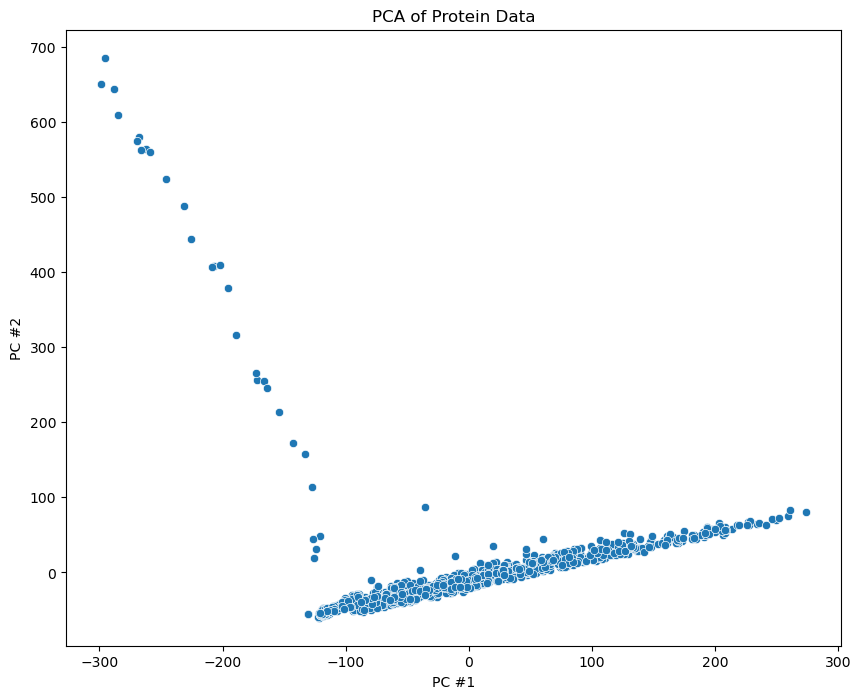

In [4]:
# plot the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, palette='Set1')
plt.title('PCA of Protein Data')
plt.xlabel('PC #1')
plt.ylabel('PC #2')
plt.show()

In [5]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in pca_df.index:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [6]:
# collect the pca values and all lineages with types into a new dataframe
pca_df['lineage'] = pca_df.index
pca_df['cell_type'] = pca_df['lineage'].map(lineage_type_dict)
pca_df.head() 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,lineage,cell_type
cell,,,,,,,,,,,,
ABa,-121.853147,-60.190404,-60.055943,57.282464,-19.157563,-2.438558,-17.975311,3.331925,1.621286,-2.877484,ABa,
ABal,-103.237793,-47.900826,-30.519409,20.999068,6.667126,24.800446,-36.556912,13.750971,15.368082,2.235905,ABal,
ABala,-111.789693,-49.831222,-27.926784,28.593342,5.801337,21.746243,-37.036009,6.286808,20.799458,0.254764,ABala,
ABalaa,-111.847374,-49.787871,-6.650101,33.807765,-0.999049,13.447652,-19.430514,1.574421,17.387115,-1.070612,ABalaa,
ABalaaa,-88.664643,-31.273815,101.674196,8.914312,5.006493,9.184200,17.007862,-17.724365,18.321907,-5.840426,ABalaaa,


In [7]:
# filter out lineages with empty cell type
pca_df_types = pca_df[pca_df['cell_type'] != '']
pca_df_no_types = pca_df[pca_df['cell_type'] == '']


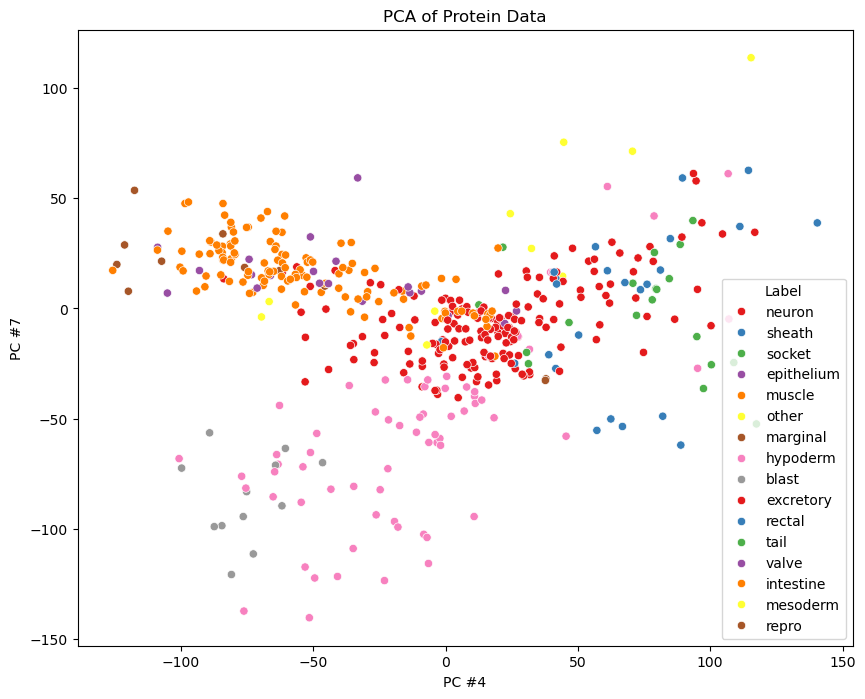

In [34]:
# plot the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC4', y='PC7', data=pca_df_types, hue='cell_type', palette='Set1')
plt.title('PCA of Protein Data')
plt.xlabel('PC #4')
plt.ylabel('PC #7')
plt.legend(title='Label')
plt.show()

/tmp/ipykernel_1605312/116535021.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='PC4', y='PC7', data=pca_df_no_types, palette='Set1')


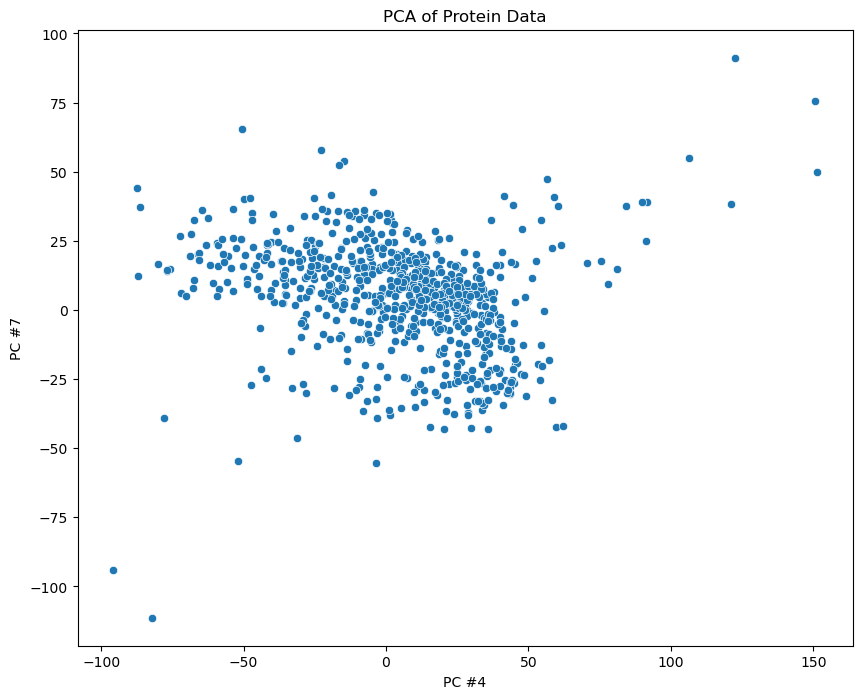

In [37]:
# plot the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC4', y='PC7', data=pca_df_no_types, palette='Set1')
plt.title('PCA of Protein Data')
plt.xlabel('PC #4')
plt.ylabel('PC #7')
plt.show()

In [11]:
all_protein_df = pd.read_csv('data/protein/aggregated_all/s3.csv', index_col=0)
all_protein_df = all_protein_df.fillna(0)

In [14]:
typed_protein_df = all_protein_df.loc[pca_df_types.index]
typed_protein_df.head()

,AHA-1_SYS135,AHR-1_SYS571,ALR-1_RW10757,ALR-1_SYS139,ALY-1_SYS619,ALY-2_SYS721,APTF-1_SYS114,ARID-1_SYS679,AST-1_SYS1190,ATF-7_SYS495,...,Y73E7A.1_SYS714,Y75B8A.6_SYS80,ZAG-1_SYS102,ZFH-2_SYS986,ZIP-3_SYS669,ZIP-8_SYS163,ZIP-8_SYS454,ZTF-11_SYS99,ZTF-30_SYS164,ZTF-6_SYS464
cell,,,,,,,,,,,,,,,,,,,,,
ABalaaaalal,0.0,0.0,0.0,0.0,60.47,36.04,0.0,9.06,3.93,0.0,...,0.0,0.00,17.60,0.0,0.0,15.66,0.00,0.00,0.0,106.90
ABalaaaalpp,0.0,0.0,0.0,0.0,54.98,10.49,0.0,4.40,0.00,0.0,...,0.0,7.44,0.00,0.0,0.0,20.24,0.46,0.00,0.0,75.46
ABalaaaarlp,0.0,0.0,0.0,0.0,61.02,28.25,0.0,10.89,0.00,0.0,...,0.0,14.76,0.00,0.0,0.0,18.78,1.01,0.00,0.0,174.00
ABalaaaarrp,0.0,0.0,0.0,0.0,58.70,26.43,0.0,9.74,0.00,0.0,...,0.0,13.39,0.00,0.0,0.0,15.31,1.90,1.82,0.0,151.98
ABalaaapall,0.0,0.0,0.0,0.0,80.72,34.85,0.0,13.70,0.49,0.0,...,0.0,12.53,8.42,0.0,0.0,20.02,1.69,0.00,0.0,173.79


In [35]:
# use a random forest regressor to predict the cell type from the protein data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X = pca_df_types.drop(columns=['lineage', 'cell_type'])
y = pca_df_types['cell_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       blast       1.00      0.33      0.50         3
  epithelium       0.00      0.00      0.00         3
   excretory       0.00      0.00      0.00         1
    hypoderm       0.56      0.62      0.59         8
   intestine       1.00      1.00      1.00         2
    marginal       0.00      0.00      0.00         1
    mesoderm       0.00      0.00      0.00         1
      muscle       0.85      0.92      0.88        24
      neuron       0.67      0.94      0.78        36
       other       0.00      0.00      0.00         2
      sheath       0.00      0.00      0.00         5
      socket       0.00      0.00      0.00         1
        tail       0.00      0.00      0.00         1
       valve       0.00      0.00      0.00         4

    accuracy                           0.70        92
   macro avg       0.29      0.27      0.27        92
weighted avg       0.58      0.70      0.62        92



/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [36]:
# get the top 20 most important features
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_20_features = feature_importances.nlargest(20)
print(top_20_features)

PC4     0.188988
PC7     0.151257
PC8     0.116713
PC1     0.103336
PC5     0.096067
PC2     0.088051
PC6     0.078866
PC3     0.068420
PC9     0.054186
PC10    0.054116
dtype: float64


In [29]:
feature_importances.nlargest(5).sum()

np.float64(0.6486930360377268)